In [1]:
import numpy as np
import segmentation_models as sm
import tensorflow as tf
import imageio
import matplotlib.pyplot as plt
import cv2
tf.config.list_physical_devices('GPU')
sm.set_framework('tf.keras')
sm.framework()
plt.rcParams["font.size"] = 32
plt.rcParams["font.family"] = 'Times New Roman'

Segmentation Models: using `keras` framework.


In [2]:
cell_det_model = sm.Unet(backbone_name = 'inceptionv3', input_shape= (256,256,3), encoder_weights = None)
cell_det_model.load_weights('det_model_color_normalization.hdf5')

seg_model = sm.Unet(backbone_name = 'inceptionv3', input_shape= (256,256,3), encoder_weights=None, classes = 3, activation = 'Softmax')
seg_model.load_weights('seg_model_color_normalization.hdf5')

preprocess_input = sm.get_preprocessing('inceptionv3')

In [3]:
img = imageio.imread('img.png')
msk = imageio.imread('msk.png')
tils = np.load('tils.npy', allow_pickle=True)

img = img[500:1100,100:700,:]
msk = msk[500:1100,100:700]
tils = np.array([[i[0]-100,i[1]-500] for i in tils if i[0]<700 and i[1]<1100 and i[0]>100 and i[1]>500])

C:\Users\Arian\AppData\Local\Temp\ipykernel_25328\146275580.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('img.png')
C:\Users\Arian\AppData\Local\Temp\ipykernel_25328\146275580.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  msk = imageio.imread('msk.png')


In [4]:
############# Apply Color Normalization on the input Img ################  
from reinhard_color_transfer import reinhard_color_transfer
t_mean = [203.02,134.58,122.55]
t_std = [40.6,5,3.68]
img_norm = reinhard_color_transfer(img,t_mean,t_std)
img_norm = preprocess_input(img_norm)
del t_mean, t_std

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


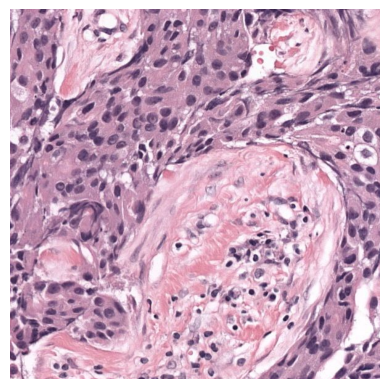

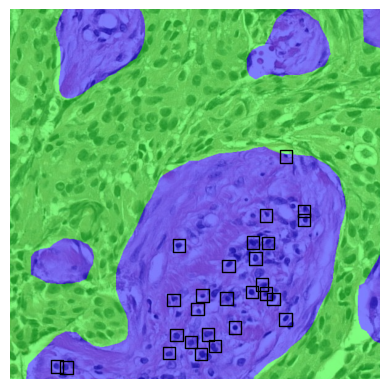

In [5]:
############# plot Img, Msk, TILs ################
def plot_img_msk_tils(img, msk, tils):    
    plt.figure()
    plt.imshow(img)
    mask = np.zeros(msk.shape+(3,))
    mask[msk==0] = [255,0,0]
    mask[msk==1] = [0,255,0]
    mask[msk==2] = [0,0,255]
    plt.imshow(mask, alpha = 0.5)
    plt.scatter(tils[:,0], tils[:,1], s = 80, c = 'none', edgecolors = 'k', marker = 's', )  
    plt.axis('off')
    
def plot_img_tils(img, tils):    
    plt.figure()
    plt.imshow(img)    
    plt.scatter(tils[:,0], tils[:,1], s = 80, c = 'none', edgecolors = 'k', marker = 's', )  
    plt.axis('off')   
    
def plot_img(img):
    plt.figure()
    plt.imshow(img)
    plt.axis('off')

def plot_msk(msk):    
    plt.figure()
    mask = np.zeros(msk.shape+(3,))
    mask[msk==0] = [255,0,0]
    mask[msk==1] = [0,255,0]
    mask[msk==2] = [0,0,255]
    plt.imshow(mask)
    plt.axis('off')

plot_img(img)
plot_img_msk_tils(img, msk, tils)

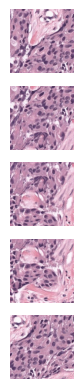

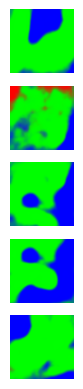

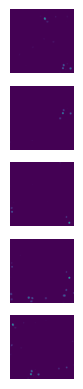

In [6]:
from crop_roi import crop_roi
patches, patches_locations =  crop_roi(img, size = 256, stride = 128)

plt.figure()
for i in range(5):
    plt.subplot(5,1,i+1)
    plt.imshow(patches[i])
    plt.axis('off')
    
patches, patches_locations =  crop_roi(img_norm, size = 256, stride = 128)
seg_predictions = seg_model.predict(np.array(patches))
det_predictions = cell_det_model.predict(np.array(patches))

plt.figure()
for i in range(5):
    plt.subplot(5,1,i+1)
    plt.imshow(seg_predictions[i])
    plt.axis('off')

plt.figure()
for i in range(5):
    plt.subplot(5,1,i+1)
    plt.imshow(det_predictions[i])
    plt.axis('off')

(-0.5, 599.5, 599.5, -0.5)

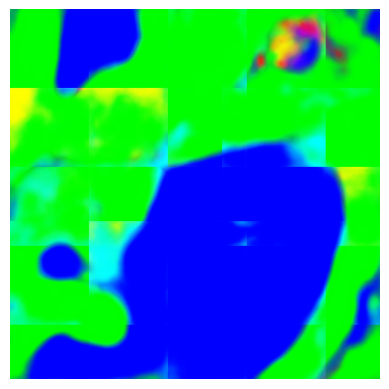

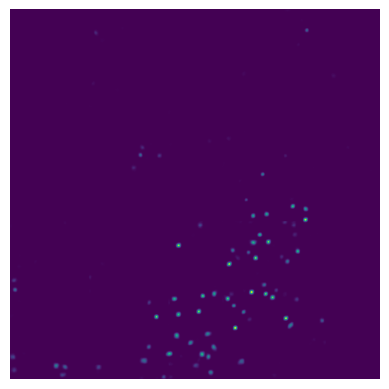

In [7]:
def stitch_patches(image, locations, predictions, n_classes):
    stitched_image = np.zeros((image.shape[0], image.shape[1], n_classes))
    for i in range(len(locations)):
        temp = np.zeros((256, 256, n_classes, 2))
        temp[:, :, :, 0] = stitched_image[locations[i][1]:locations[i][1]+256, locations[i][0]:locations[i][0]+256, :]
        temp[:, :, :, 1] = predictions[i]
        temp = np.max(temp, axis=3)
        stitched_image[locations[i][1]:locations[i][1]+256, locations[i][0]:locations[i][0]+256, :] = temp    
    return stitched_image

stiched_seg_predictions = stitch_patches(img_norm, patches_locations, seg_predictions, 3)
stiched_det_predictions = stitch_patches(img_norm, patches_locations, det_predictions, 1)

plt.figure()
plt.imshow(stiched_seg_predictions)
plt.axis('off')

plt.figure()
plt.imshow(stiched_det_predictions)
plt.axis('off')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


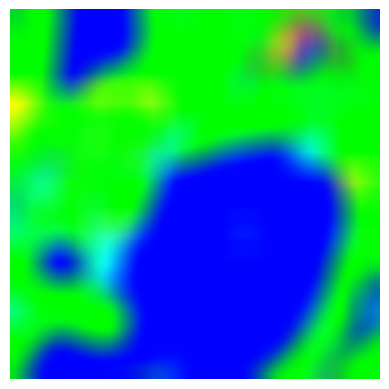

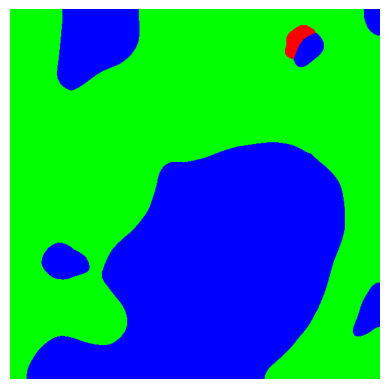

In [9]:
stiched_seg_predictions_gaussian = cv2.blur(stiched_seg_predictions, (50,50))
plt.figure()
plt.imshow(stiched_seg_predictions_gaussian)
plt.axis('off')

seg_pred = np.argmax(stiched_seg_predictions_gaussian, axis = 2)
plot_msk(seg_pred)

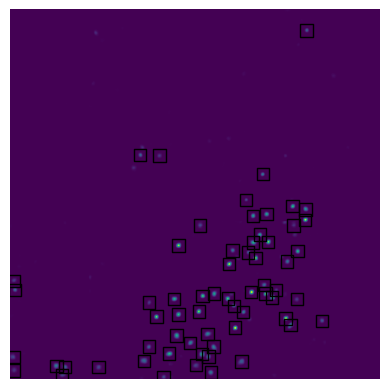

In [10]:
from scipy.spatial.distance import cdist
def extract_predictions(probabilities, confidence_threshold):    
    indices = np.meshgrid(np.arange(0,probabilities.shape[1]),np.arange(0,probabilities.shape[0]))
    indices_x = indices[0]
    indices_y = indices[1]
    indices_x = indices_x.reshape((probabilities.shape[0]*probabilities.shape[1],1))
    indices_y = indices_y.reshape((probabilities.shape[0]*probabilities.shape[1],1))    
    probabilities = probabilities.reshape((probabilities.shape[0]*probabilities.shape[1],1))    
    boxes_pred = np.concatenate((indices_x,indices_y,probabilities),axis = 1)
    boxes_pred = boxes_pred[np.argsort(boxes_pred[:, 2])[::-1]]
    boxes_pred = boxes_pred[boxes_pred[:,2]>=confidence_threshold,:]   
    return boxes_pred

def non_max_supression_distance(points, distance_threshold):
    log_val = np.ones(points.shape[0])
    wanted = []
    for i in range(points.shape[0]):
        if log_val[i]:
            hit = cdist(np.expand_dims(points[i,:2],0),points[:,:2])
            hit = np.argwhere(hit<=distance_threshold)
            log_val[hit] = 0
            wanted.append(points[i,:])
    wanted = np.array(wanted)  
    return wanted
 
def extract_TILs_from_mask(mask, confidence_threshold, distance_threshold):
    temp = extract_predictions(mask, confidence_threshold = confidence_threshold)
    tils = non_max_supression_distance(temp,distance_threshold = distance_threshold)
    return tils


det_pred = extract_TILs_from_mask(stiched_det_predictions, confidence_threshold=0.1, distance_threshold=8)
plot_img_tils(stiched_det_predictions[:,:,0], det_pred)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'Number of TILs = 63\n Number of TILs on Stroma = 55\n TILs score = 10')

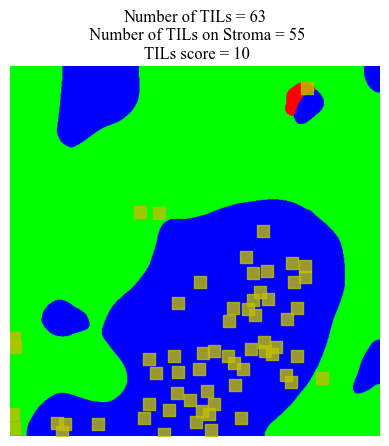

In [11]:
no_of_TILs = 0
no_of_stroma = 0
# TILs Score
if len(det_pred)>0:
    for i in det_pred:
        if seg_pred[int(i[1]),int(i[0])] == 2:
            no_of_TILs += 1
no_of_stroma += np.count_nonzero(seg_pred==2) 
tils_score = int(np.round(no_of_TILs*16*16/no_of_stroma*100))

plt.figure()
mask = np.zeros(seg_pred.shape+(3,))
mask[seg_pred==0] = [255,0,0]
mask[seg_pred==1] = [0,255,0]
mask[seg_pred==2] = [0,0,255]
plt.imshow(mask)
plt.scatter(det_pred[:,0], det_pred[:,1], s = 80, c = 'y', marker = 's',alpha = 0.8)
plt.axis('off')
total_stroma = np.sum(seg_pred==2)
plt.title('Number of TILs = '+ str(det_pred.shape[0]) + '\n Number of TILs on Stroma = '+ str(no_of_TILs)+ '\n TILs score = '+ str(tils_score),fontsize =12)